In [1]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\LENOVO\OneDrive\Desktop\Bitcoin-market-analysis\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df=pd.read_csv("../data/processed/bitcoin_features.csv")

In [9]:
df["Target"]=(df["Close"].shift(-1)>df["Close"]).astype(int)
df_ml=df.dropna().copy()

In [10]:
print(type(df_ml))

<class 'pandas.core.frame.DataFrame'>


In [11]:
features = [
    "Daily_return",
    "Volatility",
    "RSI",
    "Close_vs_MA30_ratio",
    "MA7_vs_MA30_ratio"
]

X = df_ml[features]
y = df_ml["Target"]

split = int(len(df_ml)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
explainer=shap.TreeExplainer(rf)
shap_values=explainer.shap_values(X_test)

In [18]:
print(shap_values.shape)
print(X_test.shape)

(839, 5, 2)
(839, 5)


In [23]:
import shap

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False
)
plt.tight_layout()
plt.savefig(
    "../figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [24]:
import numpy as np
import pandas as pd

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(
        shap_values[:, :, 1]
    ).mean(axis=0)
})

shap_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Daily_return,0.039962
1,Volatility,0.038454
2,RSI,0.034882
4,MA7_vs_MA30_ratio,0.031750
3,Close_vs_MA30_ratio,0.029767


In [26]:
print(type(shap_values))

<class 'numpy.ndarray'>


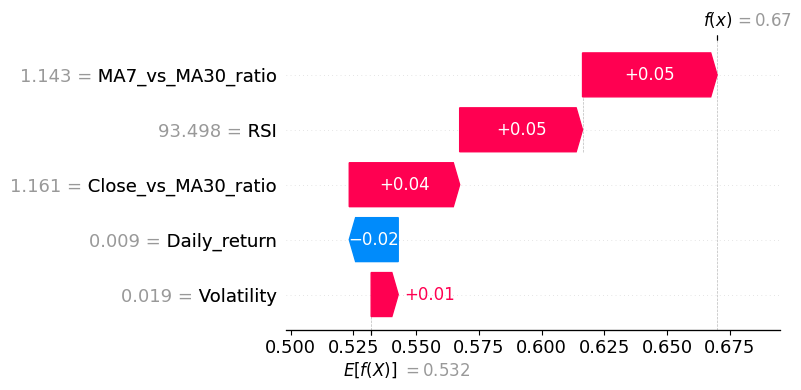

In [31]:
sample_idx = 0

# Choose the class index to explain (1 = positive class)
class_idx = 1

import numpy as np

# Convert shap_values into a 2D array (n_samples, n_features) for the desired class
if isinstance(shap_values, list):
    if len(shap_values) > class_idx:
        shap_for_class = shap_values[class_idx]
    else:
        shap_for_class = shap_values[-1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    # Possible shapes: (n_classes, n_samples, n_features) or (n_samples, n_features, n_classes)
    if shap_values.shape[0] == X_test.shape[0]:
        # (n_samples, n_features, n_classes)
        shap_for_class = shap_values[:, :, class_idx]
    elif shap_values.shape[0] == X_test.shape[1]:
        # unlikely, fallback
        shap_for_class = shap_values[:, :, class_idx]
    else:
        # assume first axis is class
        idx = min(class_idx, shap_values.shape[0] - 1)
        shap_for_class = shap_values[idx]
else:
    shap_for_class = shap_values

# Select the sample's SHAP values
sample_shap = shap_for_class[sample_idx]

# Determine base/expected value for the chosen class
base_value = explainer.expected_value
if hasattr(base_value, '__len__') and len(np.atleast_1d(base_value)) > class_idx:
    base_val = np.atleast_1d(base_value)[class_idx]
else:
    base_val = base_value

shap_exp = shap.Explanation(
    values=sample_shap,
    base_values=base_val,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(shap_exp, show=False)
plt.tight_layout()
plt.savefig("../figures/shap_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()